In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
print("Shape:", df.shape)

df.info()

df.isnull().sum()

Shape: (15509, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [4]:
data = df[['Genre','Director','Actor 1','Actor 2','Actor 3','Rating']]

data.head()

,Genre,Director,Actor 1,Actor 2,Actor 3,Rating
0,Drama,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia,NaN
1,Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,7.0
2,"Drama, Musical",Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana,NaN
3,"Comedy, Romance",Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,4.4
4,Drama,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali,NaN


In [5]:
data = data.dropna(subset=['Rating'])

data.head()

,Genre,Director,Actor 1,Actor 2,Actor 3,Rating
1,Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,7.0
3,"Comedy, Romance",Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,4.4
5,"Comedy, Drama, Musical",Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,4.7
6,"Drama, Romance, War",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,7.4
8,"Horror, Mystery, Thriller",Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.6


In [6]:
X = data.drop('Rating', axis=1)
y = data['Rating']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
categorical_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

In [9]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [10]:
model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [11]:
y_pred = model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [12]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R² Score:", round(r2,3))

MAE : 0.937
RMSE: 1.212
R² Score: 0.21


In [13]:
results = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': y_pred
})

results.head(10)

,Actual Rating,Predicted Rating
9456,3.3,5.126
14816,5.3,6.537
3213,5.7,5.098
3778,7.2,6.595
5775,3.5,4.527
12203,7.2,5.831
12305,3.8,6.410
4650,6.9,6.048
8701,5.2,6.268
4707,7.4,6.725


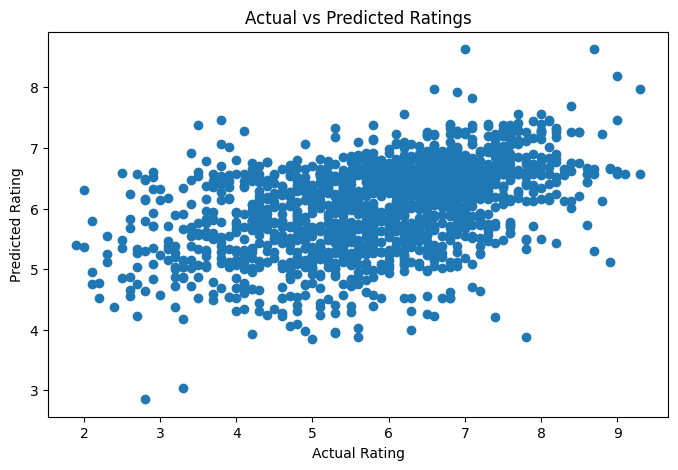

In [14]:
import matplotlib.pyplot as plt

predictions = model.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

In [15]:
new_movie = pd.DataFrame({
    'Genre':['Action'],
    'Director':['Rohit Shetty'],
    'Actor 1':['Ajay Devgn'],
    'Actor 2':['Kareena Kapoor'],
    'Actor 3':['Arjun Kapoor']
})

predicted_rating = model.predict(new_movie)

print("Predicted Rating:", round(predicted_rating[0],2))

Predicted Rating: 5.05
